# One-way ANOVA

In [4]:
import numpy as np
from scipy.stats import f_oneway

# Heights of plants for each fertilizer group
fertilizer_a = np.array([15.2,16.5,14.8,17.3, 15.9, 16.1, 17.8,15.6, 16.4,14.7,16.8,16.2,16.7,15.5,16.0,16.6,15.9, 15.3,16.5,16.9,15.7,16.3,15.8,
                         17.1, 15.4, 16.5,16.2,17.0,15.1,16.4,16.6])
fertilizer_b = np.array([14.3,13.8,13.5,14.7,13.9,14.5,14.0,14.9,13.7,14.4,14.2,14.6,14.1,13.6,14.3,14.8,14.2,14.5,14.7,13.9,14.4,13.8,14.6,14.1,
                         13.5,14.2,13.7,14.0,14.3,14.5,14.1])
fertilizer_c = np.array([17.5,18.3,17.0,18.6,17.9,17.2,18.1,17.7,18.0,17.3,17.8,18.2,17.4,18.5,17.6,18.4,18.1,17.1,18.2,18.3,17.8,18.0,17.9,18.1,17.7,
                         18.2,18.6,17.5,18.3,18.4,17.6])

# Perform one-way ANOVA
f_statistics,p_value= f_oneway(fertilizer_a, fertilizer_b,fertilizer_c)

# Interpret the results
alpha = 0.05  # Significance level
if p_value < alpha:
    print(p_value, " - Reject the null hypothesis: There is a significant difference in plant growth among the fertilizers. ")
else:
    print(p_value, " - Fail to reject the null hupothesis: There is no significant difference in plant growth among the fertilizers. ")
                         

7.79804714171454e-44  - Reject the null hypothesis: There is a significant difference in plant growth among the fertilizers. 


# Two-way ANOVA

In [5]:
import pandas as pd

# Crate a DataFrame with simulated data
data= {
    'Diet': ['Low carb', 'Low carb', 'Low carb', 'Balanced', 'Balanced', 'Balanced', 'Low Fat', 'Low Fat', 'Low Fat'],
    'Exercise': ['Sedentary', 'Moderate', 'Active', 'Sedentary', 'Moderate', 'Active', 'Sedentary', 'Moderate', 'Active'],
    'Weightloss': [2.3, 3.1, 4.2, 1.5, 2.0, 2.8, 1.0, 1.2, 1.5]
}
df= pd.DataFrame(data)
df

,Diet,Exercise,Weightloss
0,Low carb,Sedentary,2.3
1,Low carb,Moderate,3.1
2,Low carb,Active,4.2
3,Balanced,Sedentary,1.5
4,Balanced,Moderate,2.0
5,Balanced,Active,2.8
6,Low Fat,Sedentary,1.0
7,Low Fat,Moderate,1.2
8,Low Fat,Active,1.5


In [6]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit Two-way ANOVA model
model = ols('Weightloss ~ Diet + Exercise', data=df).fit()
anova_table = sm.stats.anova_lm(model)

# Interpret the results
print(anova_table)

           df    sum_sq   mean_sq          F    PR(>F)
Diet      2.0  5.828889  2.914444  23.419643  0.006190
Exercise  2.0  2.308889  1.154444   9.276786  0.031455
Residual  4.0  0.497778  0.124444        NaN       NaN


# Chi-Square Statistics

In [7]:
import numpy as np
 # Expected [25,28,21,30,45,58,57]
 # Observed [23,26,25,31,48,63,50]

chi_ind= [np.square(23-25)/25,
 np.square(26-28)/28,
 np.square(25-21)/21,
 np.square(31-30)/30,
 np.square(48-45)/45,
 np.square(63-58)/58,
 np.square(50-57)/57]

print ("Our chi square Test statistics Score = > ", np.sum(chi_ind))

Our chi square Test statistics Score = >  2.5887788436608763


# The Problem statement

In [15]:
# necessary Imports
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


In [9]:
data = pd.read_csv(r"C:\Users\DELL\Downloads\Advertising.csv") # Reading the data file


In [10]:
data.head() # Checking the first five rows from the dataset

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [11]:
data.shape

(200, 5)

In [12]:
data.info() # Printing the summary of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [13]:
data.isna().sum() # Finding the count of missing values from different columns

Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

ValueError: Scatter is not a valid plot kind

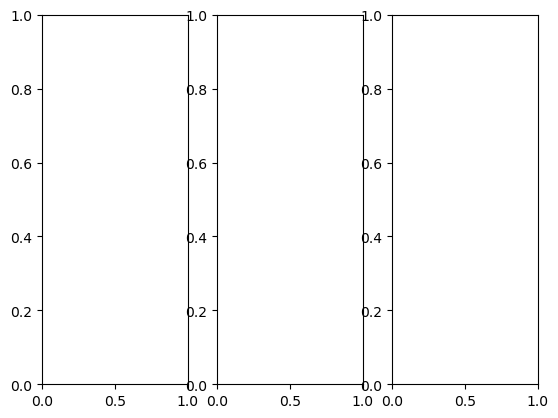

In [16]:
# Visualize the relationship between the features and the response using scatterplots
fig,axs = plt.subplots(1,3)

data.plot(kind='Scatter', x='TV', y='sales', ax= axs[0], figsize= (12,6))
data.plot(kind='Scatter', x='radio', y='sales', ax=axs[1])
data.plot(kind='Scatter', x='newspaper', y='sales', ax=axs[2])
fig.savefig('testdata.jpg')

# Linear regression

In [17]:
# Create x= feature and y =label

x=data[['TV']]
y= data.sales

# Follow the usual sklearn pattern : import, instantiate, fit

from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(x,y)


LinearRegression()

In [19]:
x=data[['radio']]
y=data.sales
from sklearn.linear_model import LinearRegression
lm=LinearRegression()
lm.fit(x,y)

LinearRegression()

In [20]:
# Print intercept and coefficients

print(lm.intercept_)
print(lm.coef_)

9.311638095158283
[0.20249578]


# Prediction using the model

In [ ]:
If the expense on TV ad is $50000, what will be the sales prediction for that market?
y=B
y= 7.032594+0.047537*50


In [21]:
# Calculate the prediction
7.032594+0.047537*50

9.409444

In [22]:
#let's to the same thing using code




In [23]:
# Let's create a DataFrame since the model expects it 
# X_new = pd.DataFrame({'TV': [50]})
# X_new.head()

In [24]:
# use the model to make predictions on a new value
lm.predict([[50]])

D:\Anaconda\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([19.43642726])

In [ ]:
# Metric to check model performance(r2_score)

In [25]:
from sklearn.metrics import r2_score
# Pass all TV records and predict sales
predicted_sales = lm.predict(x)


In [26]:
x.head()

,radio
0,37.8
1,39.3
2,45.9
3,41.3
4,10.8


In [27]:
predicted_sales

array([16.96597871, 17.26972238, 18.60619455, 17.67471395, 11.49859256,
       19.2136819 , 15.95349979, 13.28055545,  9.73687924,  9.83812713,
       10.48611364, 14.1715369 , 16.41924009, 10.85060605, 15.97374937,
       18.97068696, 16.72298377, 17.33047112, 13.46280165, 14.15128732,
       14.9207713 , 10.34436659, 12.53132105, 12.73381683, 11.86308497,
       10.02037334, 15.24476455, 12.69331768, 14.79927383, 12.55157063,
       15.04226877, 12.83506473,  9.61538177, 13.36155376,  9.59513219,
       10.14187081, 18.18095341, 19.31492979, 14.71827551, 16.94572913,
       13.82729406, 16.07499726, 14.9207713 , 11.01260268, 14.51577973,
       13.86779322, 11.31634635, 17.71521311, 12.51107147, 11.68083876,
        9.93937502, 11.25559762, 17.75571226, 18.66694329, 15.14351666,
       19.31492979, 15.00176961, 13.19955714, 19.35542895, 15.28526371,
        9.71662966, 17.95820805, 12.45032274, 15.30551328, 17.97845762,
       11.19484888, 14.29303437, 12.24782695, 14.88027214, 18.20

In [28]:
# Let's compare original sales numbers with our model predicted sales

r2_score(y_true=y,y_pred=predicted_sales)

0.33203245544529525

# Let's use statsmodels to estimate theses coefficients

In [30]:
# create  x and y
x= data[['TV', 'radio', 'newspaper']]
y= data.sales
lm= LinearRegression()
lm.fit(x,y)

# print intercept and coefficients
print('Intercept :->',lm.intercept_)
print('TV        :->',lm.coef_[0])
print('Radio     :->',lm.coef_[1])
print('Newspaper :->',lm.coef_[2])


Intercept :-> 2.9388893694594085
TV        :-> 0.04576464545539761
Radio     :-> 0.18853001691820456
Newspaper :-> -0.00103749304247632


# Check if the R-squared value goes up when you add new predictors to the model

In [31]:
# Preparing data for R2_score on TV and Radio as we can see the they are positively related co efficient
x= data[['TV','radio']]
y= data.sales

In [32]:
# let's feed features and label and train the model
lm.fit(x,y)

LinearRegression()

In [33]:
# check the R2
predicted_sales = lm.predict(x)
r2_score(y,predicted_sales)

0.8971942610828957

In [35]:
# Let's do the same for all the features
x= data[['TV','radio','newspaper']]
y=data.sales

# Training
lm.fit(x,y)

# r2
predicted_sales = lm.predict(x)
r2_score(y,predicted_sales)

0.8972106381789522